<a href="https://colab.research.google.com/github/irajamuller/error_corrections/blob/main/UA3_UA4_Estabilizadores_Bit_flip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00


In [3]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

In [31]:
def create_repetition_code_stabilizers(initial_state='0', inject_error: int = 0):
    q_codes   = QuantumRegister(3, 'code')
    q_ancilla = QuantumRegister(2, 'ancilla')
    c_syndrome = ClassicalRegister(2, 'syndrome')
    logical_bit = ClassicalRegister(1, 'logical bit')

    qc = QuantumCircuit(q_codes, q_ancilla, c_syndrome, logical_bit)

    # ═══════════════════════════════════════════════════════════════
    # 1. CODIFICAÇÃO: |psi⟩ → |psi_L⟩
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Encoding')
    # Preparação do estado inicial
    if initial_state == '1':
        qc.x(q_codes[0])

    # Encoding do código de repetição
    qc.cx(q_codes[0], q_codes[1])
    qc.cx(q_codes[0], q_codes[2])

    # ═══════════════════════════════════════════════════════════════
    # 2. OPERAÇÕES TRANSVERSAIS (
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Transversal')

    # PAULI-X TRANSVERSAL (X̄ = X⊗X⊗X)
    for i in range(3):
        qc.x(q_codes[i])

    qc.barrier(label='Step 3: Error Injection')
    if inject_error is not None:
        qc.x(q_codes[inject_error])

    # ═══════════════════════════════════════════════════════════════
    # 4. MEDIÇÃO DOS ESTABILIZADORES
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Stabilizer')

    # Estabilizador S1 = Z1 Z2
    qc.h(q_ancilla[0])
    qc.cz(q_ancilla[0], q_codes[0])
    qc.cz(q_ancilla[0], q_codes[1])
    qc.h(q_ancilla[0])
    qc.measure(q_ancilla[0], c_syndrome[0])

    qc.barrier()

    # Estabilizador S2 = Z2 Z3
    qc.h(q_ancilla[1])
    qc.cz(q_ancilla[1], q_codes[1])
    qc.cz(q_ancilla[1], q_codes[2])
    qc.h(q_ancilla[1])
    qc.measure(q_ancilla[1], c_syndrome[1])

    # ═══════════════════════════════════════════════════════════════
    # 5. CORREÇÃO CONDICIONAL
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Correction')

    with qc.if_test((c_syndrome, 1)):  # 01 → erro no qubit 0
        qc.x(q_codes[0])
    with qc.if_test((c_syndrome, 3)):  # 11 → erro no qubit 1
        qc.x(q_codes[1])
    with qc.if_test((c_syndrome, 2)):  # 10 → erro no qubit 2
        qc.x(q_codes[2])

    # ═══════════════════════════════════════════════════════════════
    # 6. DECODIFICAÇÃO
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Decoding')
    qc.cx(q_codes[0], q_codes[1])
    qc.cx(q_codes[0], q_codes[2])

    qc.x(q_codes[0])

    # ═══════════════════════════════════════════════════════════════
    # 7. MEDIÇÃO FINAL
    # ═══════════════════════════════════════════════════════════════
    qc.barrier(label='Measure')
    qc.measure(q_codes[0], logical_bit[0])

    return qc

In [32]:
qc = create_repetition_code_stabilizers()

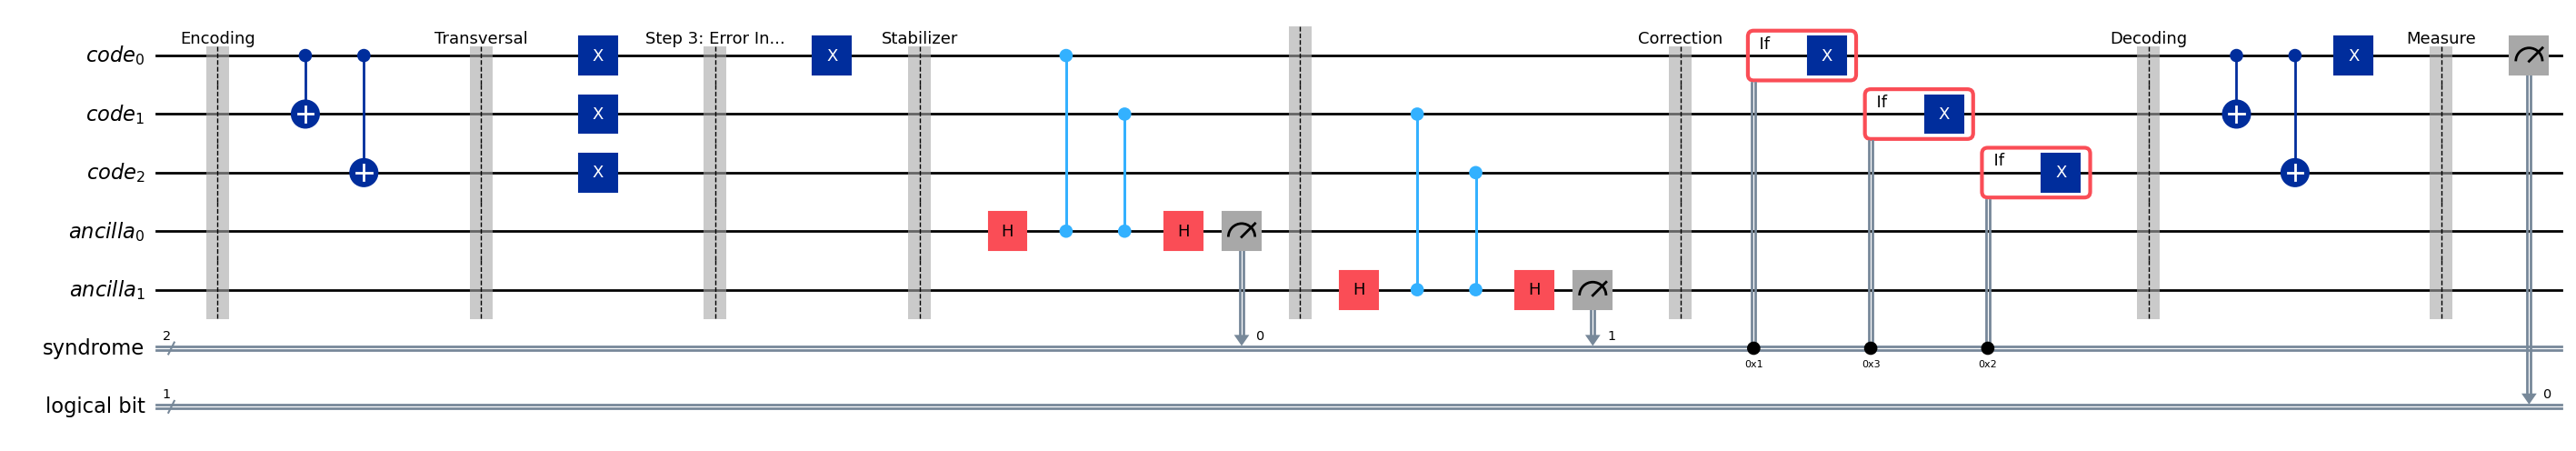

In [33]:
qc.draw('mpl', fold=-1)

In [27]:
cenarios = [
    ("Sem erro   (|0_L⟩)", '0', None),
    ("Sem erro   (|1_L⟩)", '1', None),
    ("Erro q[0]  (|0_L⟩)", '0', 0),
    ("Erro q[1]  (|0_L⟩)", '0', 1),
    ("Erro q[2]  (|0_L⟩)", '0', 2),
]

backend = AerSimulator()
for label, state, err in cenarios:
    qc = create_repetition_code_stabilizers(initial_state=state, inject_error=err)

    result  = backend.run(transpile(qc, backend), shots=1024).result()
    counts  = result.get_counts()
    print(f"{label} Contagens: {counts}")

    # Extrair o bit lógico (último bit do registro 'logical bit')
    logical_outcomes = {k[0]: v for k, v in counts.items()}

    print(f"    Medições: {logical_outcomes}")
    if '0' in logical_outcomes:
        print(f"    Probabilidade |0>: {logical_outcomes.get('0', 0)/1024*100:.1f}%")
    if '1' in logical_outcomes:
        print(f"    Probabilidade |1>: {logical_outcomes.get('1', 0)/1024*100:.1f}%")

Sem erro   (|0_L⟩) Contagens: {'0 00': 1024}
    Medições: {'0': 1024}
    Probabilidade |0>: 100.0%
Sem erro   (|1_L⟩) Contagens: {'1 00': 1024}
    Medições: {'1': 1024}
    Probabilidade |1>: 100.0%
Erro q[0]  (|0_L⟩) Contagens: {'0 01': 1024}
    Medições: {'0': 1024}
    Probabilidade |0>: 100.0%
Erro q[1]  (|0_L⟩) Contagens: {'0 11': 1024}
    Medições: {'0': 1024}
    Probabilidade |0>: 100.0%
Erro q[2]  (|0_L⟩) Contagens: {'0 10': 1024}
    Medições: {'0': 1024}
    Probabilidade |0>: 100.0%
